In [17]:
# =========================================
# CELL 1 — stable submission plotting style
# =========================================
import os
import math
import string
import numpy as np
import pandas as pd
import torch
from torch import nn
from torchdiffeq import odeint
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
np.random.seed(0)

FIG_DIR = "figs_npjsba_20260302"
os.makedirs(FIG_DIR, exist_ok=True)
print("Saving figures to:", FIG_DIR)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",

    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

CBLUE   = "#0072B2"
CORANGE = "#D55E00"
CGRAY   = "#7A7A7A"
CLIGHT  = "#E6E6E6"

poll_names_pretty = [
    "CO_GT",
    "PT08_S1_CO",
    "C6H6_GT",
    "PT08_S2_NMHC",
    "NOx_GT",
    "PT08_S3_NOx",
    "NO2_GT",
    "PT08_S4_NO2",
    "PT08_S5_O3",
]

def panel_label(ax, text):
    ax.text(
        0.02, 0.985, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10.5, fontweight="bold"
    )

def style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    ax.grid(False)

def save_png_pdf(fig, stem, dpi=400):
    png = os.path.join(FIG_DIR, stem + ".png")
    pdf = os.path.join(FIG_DIR, stem + ".pdf")
    fig.savefig(png, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    print("Saved:", png)
    print("Saved:", pdf)

def nice_limits(x, y, pad_frac=0.05):
    lo = min(np.min(x), np.min(y))
    hi = max(np.max(x), np.max(y))
    span = hi - lo
    pad = max(pad_frac * span, 1e-6)
    return lo - pad, hi + pad

Using device: cpu
Saving figures to: figs_npjsba_20260302


In [18]:
# =========================================
# CELL 2 — paths + load main AQ data
# =========================================
ROOT_DIR = os.getcwd()
BASE_DIR = os.path.join(ROOT_DIR, "preproc", "linearinterppreimp_dropNMHC")

# Main post-VAE / model files
X_post_path  = os.path.join(BASE_DIR, "AQ_Xnorm_linear_dropNMHC_postVAE_nocontrol_iter20_AQ251201004.csv")
MASK_path    = os.path.join(BASE_DIR, "AQ_MASK_linear_dropNMHC.csv")
time_map_csv = os.path.join(BASE_DIR, "AQ_time_index_map_dropNMHC.csv")
VAE_BUNDLE   = os.path.join(BASE_DIR, "vae_window3_linear9_dropNMHC_nocontrol_bundle_AQ251201004.pt")
ODE_CKPT     = os.path.join(BASE_DIR, "latentODE_window3_dropNMHC_nocontrol_H128x3_CTRL_AQ251201010.pt")
splits_path  = os.path.join(ROOT_DIR, "preproc", "AQ_splits_fixed.npz")

# Also needed for Figure 2
X_lin_path   = os.path.join(BASE_DIR, "AQ_Xnorm_linear_dropNMHC.csv")

for p in [X_post_path, MASK_path, time_map_csv, VAE_BUNDLE, ODE_CKPT, splits_path, X_lin_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

# Load
X_post_df = pd.read_csv(X_post_path)
MASK_df   = pd.read_csv(MASK_path)
time_df   = pd.read_csv(time_map_csv, parse_dates=["DateTime"])
time_df_idx = time_df.set_index("t_idx")

t_idx     = X_post_df.iloc[:, 0].to_numpy(dtype=np.int64)
X_full    = X_post_df.iloc[:, 1:].to_numpy(dtype=np.float32)   # (N,12)
MASK_full = MASK_df.to_numpy(dtype=np.float32)                 # (N,12)

N, D_full = X_full.shape
print("N, D_full:", N, D_full)

pollutant_idx = np.arange(0, 9)
meteo_idx     = np.arange(9, 12)

X_poll_norm  = X_full[:, pollutant_idx]        # (N,9)
X_meteo_norm = X_full[:, meteo_idx]            # (N,3)
MASK_poll    = MASK_full[:, pollutant_idx]     # (N,9)

poll_names = [
    "CO_GT_", "PT08_S1_CO_", "C6H6_GT_", "PT08_S2_NMHC_", "NOx_GT_",
    "PT08_S3_NOx_", "NO2_GT_", "PT08_S4_NO2_", "PT08_S5_O3_",
]

N, D_full: 9325 12


In [19]:
# =========================================
# CELL 3 — splits + valid centers + controls
# =========================================
splits = np.load(splits_path)
idx_train = splits["idx_train"]
idx_val   = splits["idx_val"]
idx_test1 = splits["idx_test1"]
idx_test2 = splits["idx_test2"]

print("Point-level split sizes:", len(idx_train), len(idx_val), len(idx_test1), len(idx_test2))

def build_window_centers(t_idx_arr, idx_centers, window_len=3):
    assert window_len == 3
    idx_centers = np.asarray(idx_centers, dtype=int)
    valid = []
    Nloc = len(t_idx_arr)
    for i in idx_centers:
        i_prev = i - 1
        i_next = i + 1
        if i_prev < 0 or i_next >= Nloc:
            continue
        if (t_idx_arr[i] - t_idx_arr[i_prev] != 1) or (t_idx_arr[i_next] - t_idx_arr[i] != 1):
            continue
        valid.append(i)
    return np.array(valid, dtype=int)

win_train_centers = build_window_centers(t_idx, idx_train)
win_val_centers   = build_window_centers(t_idx, idx_val)
win_test1_centers = build_window_centers(t_idx, idx_test1)
win_test2_centers = build_window_centers(t_idx, idx_test2)
win_all_centers   = build_window_centers(t_idx, np.arange(N))

print("Window centers:",
      "train", len(win_train_centers),
      "val", len(win_val_centers),
      "test1", len(win_test1_centers),
      "test2", len(win_test2_centers),
      "all", len(win_all_centers))

# Controls u(t): meteo + hour/day cycles + weekend
hour_of_day = time_df_idx.loc[t_idx, "HourOfDay"].to_numpy(dtype=np.float32)
dow         = time_df_idx.loc[t_idx, "DayOfWeek"].to_numpy(dtype=np.float32)
is_weekend  = time_df_idx.loc[t_idx, "IsWeekend"].to_numpy(dtype=np.float32)

hour_norm = hour_of_day / 24.0
hour_sin  = np.sin(2.0 * np.pi * hour_norm)
hour_cos  = np.cos(2.0 * np.pi * hour_norm)

dow_norm = (dow - 1.0) / 7.0
dow_sin  = np.sin(2.0 * np.pi * dow_norm)
dow_cos  = np.cos(2.0 * np.pi * dow_norm)

U_full = np.concatenate(
    [
        X_meteo_norm,
        hour_sin[:, None], hour_cos[:, None],
        dow_sin[:, None], dow_cos[:, None],
        is_weekend[:, None]
    ],
    axis=1
).astype(np.float32)

CONTROL_DIM = U_full.shape[1]
print("U_full:", U_full.shape, "CONTROL_DIM:", CONTROL_DIM)

Point-level split sizes: 6292 1348 336 1349
Window centers: train 6291 val 1348 test1 336 test2 1348 all 9323
U_full: (9325, 8) CONTROL_DIM: 8


In [20]:
# =========================================
# CELL 4 — load VAE + helper functions
# =========================================
def torch_load_compat(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

bundle = torch_load_compat(VAE_BUNDLE, map_location=device)
arch = bundle["arch"]

latent_dim = int(arch["latent_dim"])
hidden_dim = int(arch["hidden_dim"])
center_dim = int(arch["center_dim"])   # should be 9
input_dim  = int(arch["input_dim"])    # should be 27

print("VAE arch:", arch)

class Window3VAE_NoControl(nn.Module):
    def __init__(self, in_dim_flat, center_dim, latent_dim, hidden_dim):
        super().__init__()
        Act = nn.GELU
        self.encoder = nn.Sequential(
            nn.Linear(in_dim_flat, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
        )
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder   = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, center_dim),
        )

    def encode(self, x_flat):
        h = self.encoder(x_flat)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        return self.decoder(z)

vae = Window3VAE_NoControl(input_dim, center_dim, latent_dim, hidden_dim).to(device)
vae.load_state_dict(bundle["model_state"])
vae.eval()
print("VAE loaded.")

def centers_to_flat_windows(centers, X_poll):
    centers = np.asarray(centers, dtype=int)
    w = np.stack([X_poll[centers - 1], X_poll[centers], X_poll[centers + 1]], axis=1)  # (K,3,9)
    return w.reshape(len(centers), -1).astype(np.float32)                                # (K,27)

@torch.no_grad()
def encode_decode_centers_batched(centers, batch_size=4096):
    Xflat = centers_to_flat_windows(centers, X_poll_norm)
    Z_out = []
    C_out = []
    for s in range(0, len(centers), batch_size):
        xb = torch.from_numpy(Xflat[s:s+batch_size]).to(device)
        mu, _ = vae.encode(xb)
        cb = vae.decode(mu)
        Z_out.append(mu.detach().cpu().numpy())
        C_out.append(cb.detach().cpu().numpy())
    return np.concatenate(Z_out, axis=0), np.concatenate(C_out, axis=0)

print("Encoding/decoding all valid centers...")
Z_all, Chat_all = encode_decode_centers_batched(win_all_centers, batch_size=8192)
print("Z_all:", Z_all.shape, "Chat_all:", Chat_all.shape)

center_to_pos = {c: i for i, c in enumerate(win_all_centers)}

def center_to_zpos(i_center):
    return center_to_pos[int(i_center)]

VAE arch: {'variant': 'no_control', 'input_dim': 27, 'center_dim': 9, 'latent_dim': 2, 'hidden_dim': 256, 'beta': 0.05}
VAE loaded.
Encoding/decoding all valid centers...
Z_all: (9323, 2) Chat_all: (9323, 9)


In [21]:
# =========================================
# CELL 5 — load latent Neural ODE
# =========================================
state = torch_load_compat(ODE_CKPT, map_location=device)
arch_ode = state["arch"]

LATENT_DIM = int(arch_ode["latent_dim"])
HIDDEN_DIM = int(arch_ode["hidden_dim"])
T_HORIZON  = float(arch_ode["t_horizon"])

print("ODE arch:", arch_ode)

class LatentODEFunc(nn.Module):
    def __init__(self, latent_dim, control_dim, hidden_dim=128, t_horizon=3.0):
        super().__init__()
        self.latent_dim = latent_dim
        self.control_dim = control_dim
        self.t_horizon = float(t_horizon)
        self.t_horizon_int = int(round(t_horizon))
        Act = nn.Tanh
        self.net = nn.Sequential(
            nn.Linear(latent_dim + control_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, hidden_dim), Act(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, t, z, u_seq):
        t_val = float(torch.clamp(t, 0.0, self.t_horizon).item())
        if t_val <= 0:
            k0 = k1 = 0
            alpha = 0.0
        elif t_val >= self.t_horizon:
            k0 = k1 = self.t_horizon_int
            alpha = 0.0
        else:
            k0 = int(math.floor(t_val))
            k1 = k0 + 1
            alpha = t_val - k0

        k0 = max(0, min(k0, 3))
        k1 = max(0, min(k1, 3))

        u0 = u_seq[:, k0, :]
        u1 = u_seq[:, k1, :]
        u  = (1.0 - alpha) * u0 + alpha * u1

        return self.net(torch.cat([z, u], dim=-1))

ode_func = LatentODEFunc(
    latent_dim=LATENT_DIM,
    control_dim=CONTROL_DIM,
    hidden_dim=HIDDEN_DIM,
    t_horizon=T_HORIZON,
).to(device)
ode_func.load_state_dict(state["ode_state"])
ode_func.eval()

print("Neural ODE loaded.")

ODE arch: {'latent_dim': 2, 'control_dim': 8, 'hidden_dim': 128, 'num_hidden_layers': 3, 't_eval': [0.0, 1.0, 2.0, 3.0], 't_horizon': 3.0}
Neural ODE loaded.


Saved: figs_npjsba_20260302/Figure_S4.png
Saved: figs_npjsba_20260302/Figure_S4.pdf


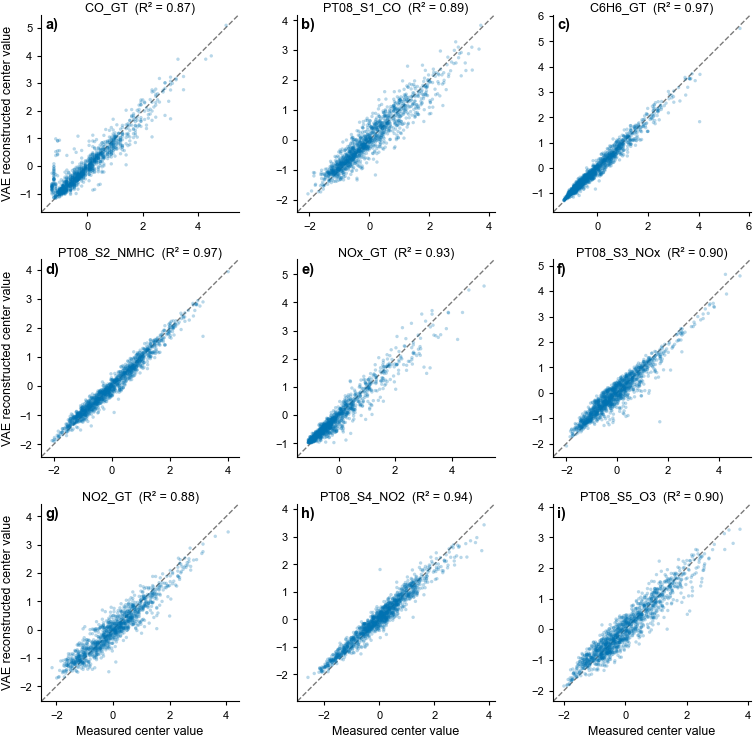

In [22]:
# =========================================
# CELL 6 — Figure S4
# =========================================
@torch.no_grad()
def plot_recon_scatter_test2_R2_npjsba():
    _, Chat_test2 = encode_decode_centers_batched(win_test2_centers, batch_size=8192)
    C_true = X_poll_norm[win_test2_centers, :]
    M_ctr  = MASK_poll[win_test2_centers, :]

    def r2_score(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        if ss_tot <= 1e-12:
            return np.nan
        return 1.0 - ss_res / ss_tot

    r2_per = []
    for p in range(center_dim):
        mask_p = (M_ctr[:, p] == 1)
        if mask_p.sum() == 0:
            r2_per.append(np.nan)
        else:
            r2_per.append(float(r2_score(C_true[mask_p, p], Chat_test2[mask_p, p])))

    fig, axes = plt.subplots(3, 3, figsize=(8.2, 7.8))
    axes = axes.ravel()

    for p, ax in enumerate(axes):
        mask_p = (M_ctr[:, p] == 1)
        x = C_true[mask_p, p]
        y = Chat_test2[mask_p, p]

        ax.scatter(
            x, y,
            s=6, alpha=0.28,
            color=CBLUE, edgecolors="none",
            rasterized=True
        )

        if len(x) > 0:
            lo, hi = nice_limits(x, y, pad_frac=0.06)
            ax.plot([lo, hi], [lo, hi], ls="--", lw=1.0, color=CGRAY, zorder=0)
            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)

        style_ax(ax)
        ax.set_aspect("equal", adjustable="box")
        panel_label(ax, f"{string.ascii_lowercase[p]})")

        r2 = r2_per[p]
        r2_str = "nan" if (not np.isfinite(r2)) else f"{r2:.2f}"
        ax.set_title(f"{poll_names_pretty[p]}  (R² = {r2_str})", pad=2)

    for i in range(9):
        if i // 3 == 2:
            axes[i].set_xlabel("Measured center value")
        if i % 3 == 0:
            axes[i].set_ylabel("VAE reconstructed center value")

    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.09, top=0.97, wspace=0.22, hspace=0.24)
    return fig

fig = plot_recon_scatter_test2_R2_npjsba()
save_png_pdf(fig, "Figure_S4", dpi=400)
plt.show()

Saved: figs_npjsba_20260302/Figure_S5.png
Saved: figs_npjsba_20260302/Figure_S5.pdf


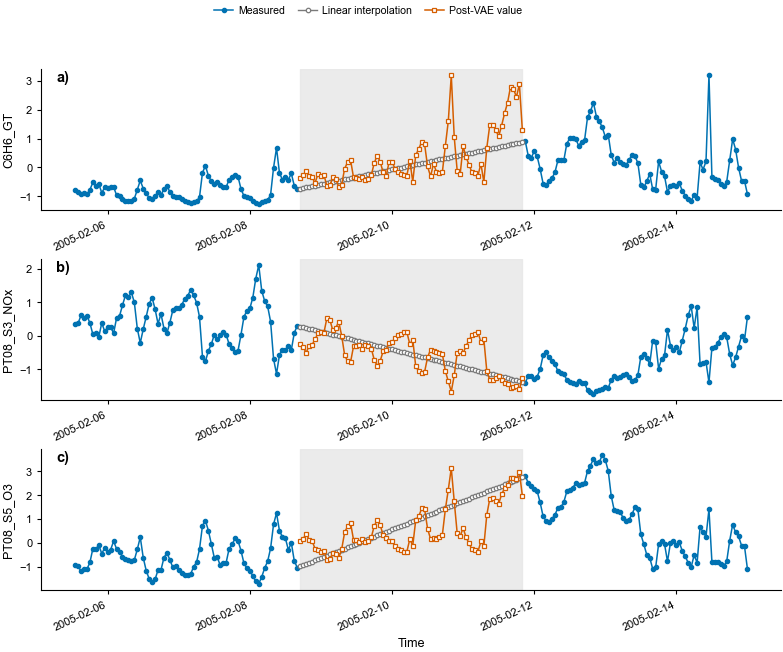

In [23]:
# =========================================
# CELL 7 — Figure S5
# =========================================
X_lin_df   = pd.read_csv(X_lin_path)
X_post_df2 = pd.read_csv(X_post_path)
MASK_df2   = pd.read_csv(MASK_path)
time_df2   = pd.read_csv(time_map_csv, parse_dates=["DateTime"])

t_idx2       = X_lin_df.iloc[:, 0].to_numpy(dtype=np.int64)
X_lin_full   = X_lin_df.iloc[:, 1:].to_numpy(dtype=np.float32)
X_post_full2 = X_post_df2.iloc[:, 1:].to_numpy(dtype=np.float32)
MASK_full2   = MASK_df2.to_numpy(dtype=np.float32)

pollutant_idx = np.arange(0, 9)
X_lin_poll2   = X_lin_full[:, pollutant_idx]
X_post_poll2  = X_post_full2[:, pollutant_idx]
MASK_poll2    = MASK_full2[:, pollutant_idx]

time_df_idx2 = time_df2.set_index("t_idx")
dt_all2      = time_df_idx2.loc[t_idx2, "DateTime"].values

poll_names2 = [
    "CO_GT", "PT08_S1_CO", "C6H6_GT", "PT08_S2_NMHC", "NOx_GT",
    "PT08_S3_NOx", "NO2_GT", "PT08_S4_NO2", "PT08_S5_O3",
]

def largest_missing_run(missing_bool):
    idx_missing = np.where(missing_bool)[0]
    if idx_missing.size == 0:
        return None, 0

    best_start = idx_missing[0]
    best_len = 1
    cur_start = idx_missing[0]
    cur_len = 1

    for prev, cur in zip(idx_missing[:-1], idx_missing[1:]):
        if cur == prev + 1:
            cur_len += 1
        else:
            if cur_len > best_len:
                best_len = cur_len
                best_start = cur_start
            cur_start = cur
            cur_len = 1

    if cur_len > best_len:
        best_len = cur_len
        best_start = cur_start

    return best_start, best_len

def plot_linear_vs_postVAE_npjsba():
    keep_names = ["C6H6_GT", "PT08_S3_NOx", "PT08_S5_O3"]
    keep_idx = [poll_names2.index(nm) for nm in keep_names]

    fig, axes = plt.subplots(len(keep_idx), 1, figsize=(8.6, 6.6), sharex=False)
    if len(keep_idx) == 1:
        axes = [axes]

    legend_handles = None
    legend_labels  = None

    for ii, p in enumerate(keep_idx):
        ax = axes[ii]
        missing_p = (MASK_poll2[:, p] == 0)
        start_idx, K = largest_missing_run(missing_p)

        if start_idx is None or K == 0:
            ax.text(
                0.5, 0.5, "No missing interval found",
                transform=ax.transAxes, ha="center", va="center"
            )
            ax.set_ylabel(poll_names2[p])
            style_ax(ax)
            continue

        left  = max(0, start_idx - K)
        right = min(len(X_lin_poll2), start_idx + 2 * K)
        idx_win = np.arange(left, right)

        dt_win   = dt_all2[idx_win]
        y_lin    = X_lin_poll2[idx_win, p]
        y_post   = X_post_poll2[idx_win, p]
        miss_win = missing_p[idx_win]

        g0_local = start_idx - left
        g1_local = g0_local + K - 1

        ax.axvspan(dt_win[g0_local], dt_win[g1_local], color=CLIGHT, alpha=0.8, zorder=0)

        meas_mask = ~miss_win
        h_meas = h_linimp = h_post = None

        if np.any(meas_mask):
            (h_meas,) = ax.plot(
                dt_win[meas_mask], y_lin[meas_mask],
                "o-", color=CBLUE, markersize=3.0, lw=1.1,
                label="Measured"
            )

        if np.any(miss_win):
            (h_linimp,) = ax.plot(
                dt_win[miss_win], y_lin[miss_win],
                "o-", color=CGRAY, markersize=3.2, lw=1.0,
                markerfacecolor="white", markeredgewidth=0.9,
                label="Linear interpolation"
            )
            (h_post,) = ax.plot(
                dt_win[miss_win], y_post[miss_win],
                "s-", color=CORANGE, markersize=3.2, lw=1.1,
                markerfacecolor="white", markeredgewidth=0.9,
                label="Post-VAE value"
            )

        panel_label(ax, f"{string.ascii_lowercase[ii]})")
        ax.set_ylabel(poll_names2[p])
        style_ax(ax)

        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        plt.setp(ax.get_xticklabels(), rotation=25, ha="right")

        if legend_handles is None and (h_meas is not None) and (h_linimp is not None) and (h_post is not None):
            legend_handles = [h_meas, h_linimp, h_post]
            legend_labels  = ["Measured", "Linear interpolation", "Post-VAE value"]

    axes[-1].set_xlabel("Time")

    if legend_handles is not None:
        fig.legend(
            legend_handles, legend_labels,
            loc="upper center", bbox_to_anchor=(0.5, 0.995),
            ncol=3, frameon=False,
            fontsize=7.6,
            handlelength=1.8,
            handletextpad=0.5,
            columnspacing=1.2,
            borderaxespad=0.2
        )

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.10, top=0.89, hspace=0.34)
    return fig

fig = plot_linear_vs_postVAE_npjsba()
save_png_pdf(fig, "Figure_S5", dpi=400)
plt.show()

Saved: figs_npjsba_20260302/Figure_5.png
Saved: figs_npjsba_20260302/Figure_5.pdf


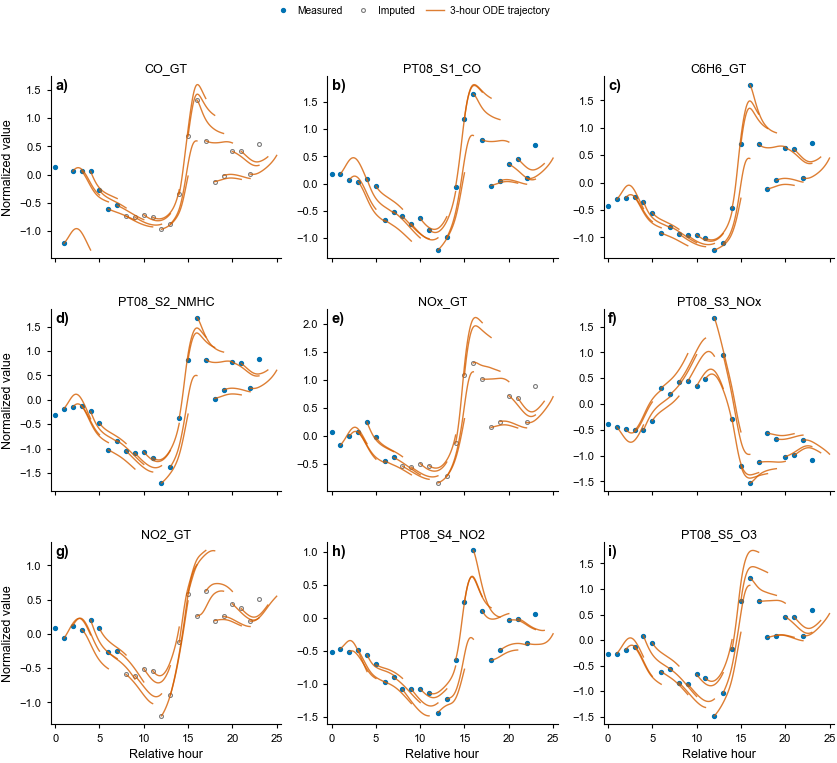

In [24]:
# =========================================
# CELL 8 — Figure 5
# =========================================
def center_to_zidx(i_center):
    return i_center - 1

@torch.no_grad()
def compute_three_hour_trajs_for_block_diff(rows, X_block, n_time_points=75, eps_fd=1e-3):
    rows = np.asarray(rows, dtype=int)
    assert len(rows) == 24
    centers_pos = list(range(1, 23))
    traj_list = []

    t_plot = torch.linspace(0., 3., n_time_points, device=device)
    dt = (t_plot[1] - t_plot[0]).item()

    for j in centers_pos:
        c = rows[j]

        z0 = torch.from_numpy(Z_all[center_to_zidx(c)]).unsqueeze(0).to(device)

        c0 = c
        c1 = min(c + 1, N - 1)
        c2 = min(c + 2, N - 1)
        c3 = min(c + 3, N - 1)
        u_seq_np = np.stack([U_full[c0], U_full[c1], U_full[c2], U_full[c3]], axis=0)[None, ...]
        u_seq = torch.from_numpy(u_seq_np).to(device)

        def ode_rhs(t, z):
            return ode_func(t, z, u_seq)

        z_traj = odeint(ode_rhs, z0, t_plot, method="dopri5").squeeze(1)

        dxdt = torch.zeros((n_time_points, center_dim), device=device)
        for ti in range(n_time_points):
            z_t = z_traj[ti].unsqueeze(0)
            dzdt_t = ode_func(t_plot[ti], z_t, u_seq)

            x_t   = vae.decode(z_t)
            x_eps = vae.decode(z_t + eps_fd * dzdt_t)
            dxdt[ti] = ((x_eps - x_t) / eps_fd).squeeze(0)

        x_traj = torch.zeros((n_time_points, center_dim), device=device)
        x_traj[0] = torch.from_numpy(X_block[j]).to(device)

        for ti in range(n_time_points - 1):
            x_traj[ti + 1] = x_traj[ti] + 0.5 * (dxdt[ti] + dxdt[ti + 1]) * dt

        traj_list.append(x_traj.cpu().numpy())

    return traj_list, centers_pos, t_plot.cpu().numpy()

def plot_3hNeuralODE_npjsba(ex_id=4):
    window_len = 24
    num_examples = 5
    starts = np.linspace(0, N - window_len, num_examples, dtype=int)

    start = starts[ex_id - 1]
    rows = np.arange(start, start + window_len, dtype=int)
    t_rel = np.arange(window_len)

    X_block = X_poll_norm[rows]
    M_block = MASK_poll[rows]

    traj_list, centers_pos, t_plot_np = compute_three_hour_trajs_for_block_diff(
        rows, X_block, n_time_points=75, eps_fd=1e-3
    )

    fig, axes = plt.subplots(3, 3, figsize=(8.8, 7.9), sharex=True)
    axes = axes.ravel()

    line_handle = None
    meas_handle = None
    imp_handle = None

    for d in range(9):
        ax = axes[d]
        y = X_block[:, d]
        meas = M_block[:, d] == 1
        imp  = ~meas

        hm, = ax.plot(
            t_rel[meas], y[meas],
            "o", color=CBLUE, markersize=2.8,
            label="Measured"
        )
        hi, = ax.plot(
            t_rel[imp], y[imp],
            "o", color=CGRAY, markersize=2.8,
            markerfacecolor="white", markeredgewidth=0.8,
            label="Imputed"
        )

        for k, j in enumerate(centers_pos):
            t_seg = j + t_plot_np
            x_traj = traj_list[k][:, d]
            hl, = ax.plot(
                t_seg, x_traj,
                "-", color=CORANGE, linewidth=1.0, alpha=0.80,
                label="3-hour ODE trajectory"
            )
            if line_handle is None:
                line_handle = hl

        if meas_handle is None:
            meas_handle = hm
        if imp_handle is None:
            imp_handle = hi

        panel_label(ax, f"{string.ascii_lowercase[d]})")
        ax.set_title(poll_names_pretty[d], pad=3)
        style_ax(ax)

        if d % 3 == 0:
            ax.set_ylabel("Normalized value")
        if d >= 6:
            ax.set_xlabel("Relative hour")

        ax.set_xlim(-0.5, 25.5)

    fig.legend(
        [meas_handle, imp_handle, line_handle],
        ["Measured", "Imputed", "3-hour ODE trajectory"],
        loc="upper center", bbox_to_anchor=(0.5, 0.997),
        ncol=3, frameon=False,
        fontsize=7.4,
        handlelength=1.8,
        handletextpad=0.5,
        columnspacing=1.1,
        borderaxespad=0.2
    )

    fig.subplots_adjust(left=0.09, right=0.98, bottom=0.08, top=0.90, wspace=0.20, hspace=0.28)
    return fig

fig = plot_3hNeuralODE_npjsba(ex_id=4)
save_png_pdf(fig, "Figure_5", dpi=400)
plt.show()